In [1]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import numpy as np


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
transform = transforms.ToTensor()

In [4]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)


test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [5]:
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [6]:
train_size = 54000
val_size = 6000

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

In [7]:
print(len(train_dataset))
print(len(val_dataset))

54000
6000


In [8]:
batch_size = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

torch.Size([1, 28, 28])
9


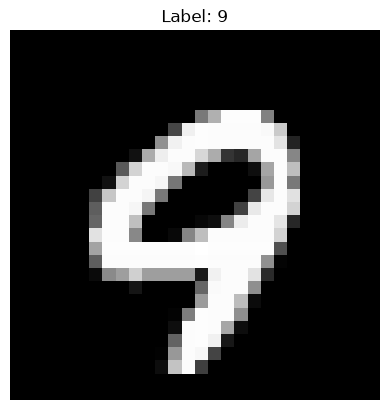

In [9]:
image, label = train_dataset[0]


print(image.shape)
print(label)


plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [10]:
class MNISTClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784, 256),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 10)

        )


    def forward(self, x):

        return self.network(x)

In [11]:
model = MNISTClassifier()

model = model.to(device)

print(model)

MNISTClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [12]:
images, labels = next(iter(train_loader))

images = images.to(device)
print(images.shape)

torch.Size([64, 1, 28, 28])


In [13]:
outputs = model(images)

print(outputs.shape)

torch.Size([64, 10])


In [14]:
# Loss function
criterion = nn.CrossEntropyLoss()


# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


# Training settings
epochs = 10

best_val_accuracy = 0

In [15]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )


        # Clear old gradients
        optimizer.zero_grad()


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        running_loss += loss.item()


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)



    epoch_loss = running_loss / len(loader)

    epoch_accuracy = correct / total


    return epoch_loss, epoch_accuracy

In [16]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in loader:


            images = images.to(device)
            labels = labels.to(device)


            outputs = model(images)


            loss = criterion(
                outputs,
                labels
            )


            running_loss += loss.item()


            predictions = torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                predictions == labels
            ).sum().item()


            total += labels.size(0)



    loss = running_loss / len(loader)

    accuracy = correct / total


    return loss, accuracy

In [17]:
import os

print(os.getcwd())

d:\Computer Vision Projects\2.MNIST Digit Recognizer\notebooks


In [18]:
import os

os.makedirs("models", exist_ok=True)

In [19]:
for epoch in range(epochs):


    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )


    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )


    print(
        f"Epoch [{epoch+1}/{epochs}]"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_acc*100:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_acc*100:.2f}%"
    )


    print("-----------------------------")


    # Save best model

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "models/best_model.pth"
        )

        print("Model Saved!")

Epoch [1/10]
Train Loss: 0.2738
Train Accuracy: 92.26%
Validation Loss: 0.1564
Validation Accuracy: 95.52%
-----------------------------
Model Saved!
Epoch [2/10]
Train Loss: 0.1467
Train Accuracy: 95.63%
Validation Loss: 0.1232
Validation Accuracy: 96.65%
-----------------------------
Model Saved!
Epoch [3/10]
Train Loss: 0.1146
Train Accuracy: 96.58%
Validation Loss: 0.1037
Validation Accuracy: 97.17%
-----------------------------
Model Saved!
Epoch [4/10]
Train Loss: 0.0991
Train Accuracy: 96.97%
Validation Loss: 0.0990
Validation Accuracy: 97.17%
-----------------------------
Epoch [5/10]
Train Loss: 0.0882
Train Accuracy: 97.35%
Validation Loss: 0.0961
Validation Accuracy: 97.23%
-----------------------------
Model Saved!
Epoch [6/10]
Train Loss: 0.0804
Train Accuracy: 97.47%
Validation Loss: 0.0909
Validation Accuracy: 97.30%
-----------------------------
Model Saved!
Epoch [7/10]
Train Loss: 0.0744
Train Accuracy: 97.69%
Validation Loss: 0.0913
Validation Accuracy: 97.40%
------

In [20]:
model = MNISTClassifier()

model = model.to(device)

In [21]:
model.load_state_dict(
    torch.load(
        "models/best_model.pth"
    )
)

<All keys matched successfully>

In [22]:
model.eval()

MNISTClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [23]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion
)


print(
    f"Test Accuracy: {test_accuracy*100:.2f}%"
)

Test Accuracy: 97.82%


In [24]:
image, label = test_dataset[0]


image_input = image.unsqueeze(0)

image_input = image_input.to(device)



with torch.no_grad():

    output = model(image_input)


prediction = torch.argmax(
    output,
    dim=1
)


print(
    "Predicted:",
    prediction.item()
)

print(
    "Actual:",
    label
)

Predicted: 7
Actual: 7


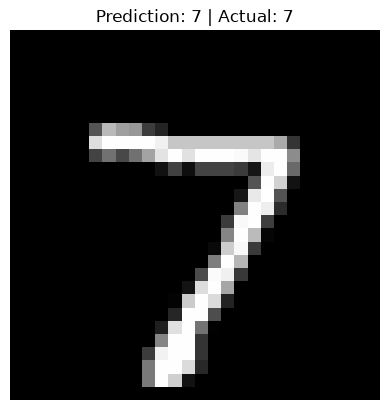

In [25]:
plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Prediction: {prediction.item()} | Actual: {label}"
)

plt.axis("off")

plt.show()

In [26]:
from PIL import Image
import torchvision.transforms as transforms

In [27]:
image = Image.open("../images/my_digit.png")

In [28]:
print(image)

<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=222x281 at 0x269F3C86490>


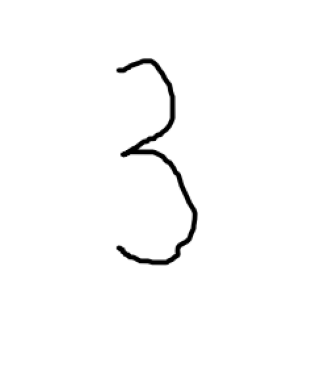

In [29]:
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [30]:
transform = transforms.Compose([
    
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize((28,28)),

    transforms.ToTensor()

])

In [31]:
input_image = transform(image)

In [32]:
print(input_image.shape)

torch.Size([1, 28, 28])


In [33]:
input_image = input_image.unsqueeze(0)

In [34]:
print(input_image.shape)

torch.Size([1, 1, 28, 28])


In [35]:
input_image = input_image.to(device)

In [36]:
model.eval()

with torch.no_grad():

    output = model(input_image)


prediction = torch.argmax(
    output,
    dim=1
)


print(
    "Predicted digit:",
    prediction.item()
)

Predicted digit: 3
